# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( accuracy_score, precision_score,recall_score,f1_score,roc_auc_score, confusion_matrix)

sns.set_theme()


# Data Collection

In [2]:
url = "https://cdn.theforage.com/vinternships/companyassets/Zbnc2o4ok6kD2NEXx/2kCX23cgKgCumeEam/1721851467492/Customer_Churn_Data_Large.xlsx"

excel = pd.ExcelFile(url)

In [3]:
print(excel.sheet_names)

['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


In [4]:
df1 = pd.read_excel(url, sheet_name=0)
df2 = pd.read_excel(url, sheet_name=1)
df3 = pd.read_excel(url, sheet_name=2)
df4 = pd.read_excel(url, sheet_name=3)
df5 = pd.read_excel(url, sheet_name=4)

# Data PreProcessing

## DF1

In [5]:
df1.isnull().sum()

CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64

In [6]:
df1.duplicated().sum()

np.int64(0)

In [7]:
new_df1 = df1.copy()
new_df1['Gender'] = new_df1['Gender'].map({'M':0, 'F':1})
new_df1['IncomeLevel'] =  new_df1['IncomeLevel'].map({'Low':0, 'Medium':1, 'High':2})
new_df1 = pd.get_dummies(new_df1, columns=['MaritalStatus'],drop_first=True, dtype=int)

new_df1.head()

,CustomerID,Age,Gender,IncomeLevel,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,1,62,0,0,0,1,0
1,2,65,0,0,1,0,0
2,3,18,0,0,0,1,0
3,4,21,0,0,0,0,1
4,5,21,0,1,0,0,0


In [8]:
new_df1.describe()

,CustomerID,Age,Gender,IncomeLevel,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.00000
mean,500.500000,43.267000,0.513000,1.024000,0.2610,0.215000,0.27600
std,288.819436,15.242311,0.500081,0.821035,0.4394,0.411028,0.44724
min,1.000000,18.000000,0.000000,0.000000,0.0000,0.000000,0.00000
25%,250.750000,30.000000,0.000000,0.000000,0.0000,0.000000,0.00000
50%,500.500000,43.000000,1.000000,1.000000,0.0000,0.000000,0.00000
75%,750.250000,56.000000,1.000000,2.000000,1.0000,0.000000,1.00000
max,1000.000000,69.000000,1.000000,2.000000,1.0000,1.000000,1.00000


## DF2

In [9]:
df2.isnull().sum()

CustomerID         0
TransactionID      0
TransactionDate    0
AmountSpent        0
ProductCategory    0
dtype: int64

In [10]:
df2.duplicated().sum()

np.int64(0)

In [11]:
new_df2 = df2.copy()
new_df2 = pd.get_dummies(new_df2, columns=['ProductCategory'],drop_first=True, dtype=int)

### Standardization

In [12]:
scaler_am = StandardScaler()
new_df2['AmountSpent'] = scaler_am.fit_transform(new_df2[['AmountSpent']])

In [13]:
new_df2.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture,ProductCategory_Groceries
0,1,7194,2022-03-27,1.165610,0,1,0,0
1,2,7250,2022-08-08,-1.376208,1,0,0,0
2,2,9660,2022-07-25,-0.374076,0,1,0,0
3,2,2998,2022-01-25,-1.050343,0,0,1,0
4,2,1228,2022-07-24,1.031116,1,0,0,0


## DF3

In [14]:
df3.isnull().sum()

CustomerID          0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
dtype: int64

In [15]:
df3.duplicated().sum()

np.int64(0)

In [16]:
new_df3 = df3.copy()
new_df3 = pd.get_dummies(new_df3, columns=['InteractionType'],drop_first=True, dtype=int)
new_df3 = pd.get_dummies(new_df3, columns=['ResolutionStatus'],drop_first=True, dtype=int)

new_df3.head()

,CustomerID,InteractionID,InteractionDate,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved
0,1,6363,2022-03-31,0,1,0
1,2,3329,2022-03-17,0,1,0
2,3,9976,2022-08-24,0,1,0
3,4,7354,2022-11-18,0,1,0
4,4,5393,2022-07-03,0,1,1


## DF4

In [17]:
new_df4 = df4.copy()
new_df4 = pd.get_dummies(new_df4, columns=['ServiceUsage'],drop_first=True, dtype=int)

###  Standardization

In [18]:
scaler_lf = StandardScaler()
new_df4['LoginFrequency'] = scaler_lf.fit_transform(new_df4[['LoginFrequency']])

In [19]:
new_df4.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,2023-10-21,0.575702,0,0
1,2,2023-12-05,-1.488513,0,1
2,3,2023-11-15,-1.630872,0,1
3,4,2023-08-25,-1.702052,0,1
4,5,2023-10-27,1.073961,0,1


## DF5

In [20]:
merged_df = df1.merge(df5, on='CustomerID')

merged_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus
0,1,62,M,Single,Low,0
1,2,65,M,Married,Low,1
2,3,18,M,Single,Low,0
3,4,21,M,Widowed,Low,0
4,5,21,M,Divorced,Medium,0


In [21]:
transaction_summary = df2.groupby('CustomerID')['AmountSpent'].agg(
    ['sum', 'count', 'mean']
).reset_index()
transaction_summary.columns = [
    'CustomerID',
    'TotalSpent',
    'TransactionCount',
    'AvgSpent'
]
interaction_counts = (
    df3.groupby('CustomerID')
    .size()
    .reset_index(name='InteractionCount')
)

In [22]:
transaction_summary.head()

,CustomerID,TotalSpent,TransactionCount,AvgSpent
0,1,416.50,1,416.50000
1,2,1547.42,7,221.06000
2,3,1702.98,6,283.83000
3,4,917.29,5,183.45800
4,5,2001.49,8,250.18625


In [23]:
interaction_counts = df3.groupby('CustomerID').size()
interaction_counts.head()

CustomerID
1    1
2    1
3    1
4    2
6    1
dtype: int64

In [24]:
merged_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus
0,1,62,M,Single,Low,0
1,2,65,M,Married,Low,1
2,3,18,M,Single,Low,0
3,4,21,M,Widowed,Low,0
4,5,21,M,Divorced,Medium,0


In [25]:
# Complaint count

complaint_count = (
    df3[df3['InteractionType'] == 'Complaint']
    .groupby('CustomerID')
    .size()
    .reset_index(name='ComplaintCount')
)

In [26]:

# Unresolved count

unresolved_count = (
    df3[df3['ResolutionStatus'] == 'Unresolved']
    .groupby('CustomerID')
    .size()
    .reset_index(name='UnresolvedCount')
)

In [27]:

# Merge transaction summary

merged_df = merged_df.merge(
    transaction_summary,
    on='CustomerID',
    how='left'
)

In [28]:

# Merge interaction counts

merged_df = merged_df.merge(
    interaction_counts.reset_index(name='InteractionCount'),
    left_on='CustomerID',
    right_on='CustomerID',
    how='left'
)

In [29]:

# Merge complaint counts

merged_df = merged_df.merge(
    complaint_count,
    on='CustomerID',
    how='left'
)

In [30]:

# Merge unresolved counts

merged_df = merged_df.merge(
    unresolved_count,
    on='CustomerID',
    how='left'
)

In [31]:

# Merge login/service dataset

merged_df = merged_df.merge(
    df4,
    on='CustomerID',
    how='left'
)

In [32]:

# Fill missing values

merged_df = merged_df.fillna(0)

In [33]:

# Inspect final merged dataset

merged_df.head()

merged_df.info()

merged_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        1000 non-null   int64         
 1   Age               1000 non-null   int64         
 2   Gender            1000 non-null   str           
 3   MaritalStatus     1000 non-null   str           
 4   IncomeLevel       1000 non-null   str           
 5   ChurnStatus       1000 non-null   int64         
 6   TotalSpent        1000 non-null   float64       
 7   TransactionCount  1000 non-null   int64         
 8   AvgSpent          1000 non-null   float64       
 9   InteractionCount  1000 non-null   float64       
 10  ComplaintCount    1000 non-null   float64       
 11  UnresolvedCount   1000 non-null   float64       
 12  LastLoginDate     1000 non-null   datetime64[us]
 13  LoginFrequency    1000 non-null   int64         
 14  ServiceUsage      1000 non-null   st

,CustomerID,Age,ChurnStatus,TotalSpent,TransactionCount,AvgSpent,InteractionCount,ComplaintCount,UnresolvedCount,LastLoginDate,LoginFrequency
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000
mean,500.500000,43.267000,0.204000,1267.074950,5.054000,248.806511,1.002000,0.335000,0.479000,2023-07-05 21:28:48,25.912000
min,1.000000,18.000000,0.000000,9.800000,1.000000,9.800000,0.000000,0.000000,0.000000,2023-01-01 00:00:00,1.000000
25%,250.750000,30.000000,0.000000,626.685000,3.000000,203.734167,0.000000,0.000000,0.000000,2023-04-08 00:00:00,13.750000
50%,500.500000,43.000000,0.000000,1232.880000,5.000000,250.121458,1.000000,0.000000,0.000000,2023-07-10 12:00:00,27.000000
75%,750.250000,56.000000,0.000000,1791.902500,7.000000,295.023854,2.000000,1.000000,1.000000,2023-10-01 06:00:00,38.000000
max,1000.000000,69.000000,1.000000,3386.040000,9.000000,496.990000,2.000000,2.000000,2.000000,2023-12-31 00:00:00,49.000000
std,288.819436,15.242311,0.403171,738.590013,2.603433,79.372766,0.816494,0.546877,0.621245,NaN,14.055953


In [34]:
model_df = merged_df.copy()

In [35]:
# Gender encoding
model_df['Gender'] = model_df['Gender'].map({
    'M': 0,
    'F': 1
})

# Income level encoding
model_df['IncomeLevel'] = model_df['IncomeLevel'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [36]:
model_df = pd.get_dummies(
    model_df,
    columns=[
        'MaritalStatus',
        'ServiceUsage'
    ],
    drop_first=True,
    dtype=int
)

model_df.head()

,CustomerID,Age,Gender,IncomeLevel,ChurnStatus,TotalSpent,TransactionCount,AvgSpent,InteractionCount,ComplaintCount,UnresolvedCount,LastLoginDate,LoginFrequency,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,62,0,0,0,416.50,1,416.50000,1.0,0.0,0.0,2023-10-21,34,0,1,0,0,0
1,2,65,0,0,1,1547.42,7,221.06000,1.0,0.0,0.0,2023-12-05,5,1,0,0,0,1
2,3,18,0,0,0,1702.98,6,283.83000,1.0,0.0,0.0,2023-11-15,3,0,1,0,0,1
3,4,21,0,0,0,917.29,5,183.45800,2.0,0.0,1.0,2023-08-25,2,0,0,1,0,1
4,5,21,0,1,0,2001.49,8,250.18625,0.0,0.0,0.0,2023-10-27,41,0,0,0,0,1


In [37]:
scaler = StandardScaler()

numerical_cols = [
    'Age',
    'TotalSpent',
    'AvgSpent',
    'TransactionCount',
    'InteractionCount',
    'ComplaintCount',
    'UnresolvedCount',
    'LoginFrequency'
]

model_df[numerical_cols] = scaler.fit_transform(
    model_df[numerical_cols]
)

model_df.head()

,CustomerID,Age,Gender,IncomeLevel,ChurnStatus,TotalSpent,TransactionCount,AvgSpent,InteractionCount,ComplaintCount,UnresolvedCount,LastLoginDate,LoginFrequency,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,1.229628,0,0,0,-1.152196,-1.557954,2.113790,-0.002451,-0.612876,-0.771419,2023-10-21,0.575702,0,1,0,0,0
1,2,1.426547,0,0,1,0.379758,0.747849,-0.349747,-0.002451,-0.612876,-0.771419,2023-12-05,-1.488513,1,0,0,0,1
2,3,-1.658518,0,0,0,0.590481,0.363548,0.441474,-0.002451,-0.612876,-0.771419,2023-11-15,-1.630872,0,1,0,0,1
3,4,-1.461599,0,0,0,-0.473822,-0.020752,-0.823723,1.222911,-0.612876,0.839059,2023-08-25,-1.702052,0,0,1,0,1
4,5,-1.461599,0,1,0,0.994845,1.132149,0.017392,-1.227812,-0.612876,-0.771419,2023-10-27,1.073961,0,0,0,0,1


In [38]:
model_df.to_csv('model.csv',index=False)

# EDA

##  CHURN DISTRIBUTION

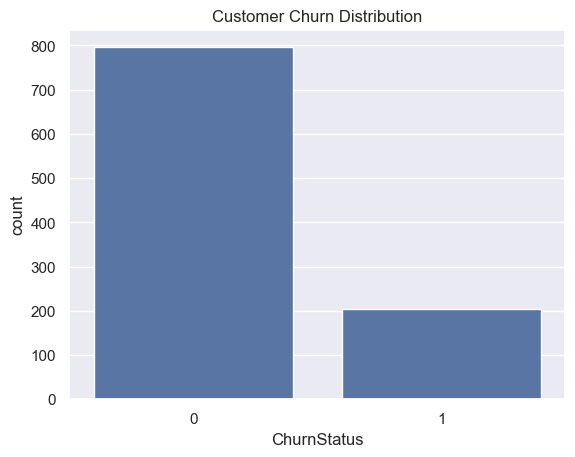

In [39]:
sns.countplot(x='ChurnStatus', data=merged_df)

plt.title('Customer Churn Distribution')

plt.show()

##  LOGIN FREQUENCY VS CHURN

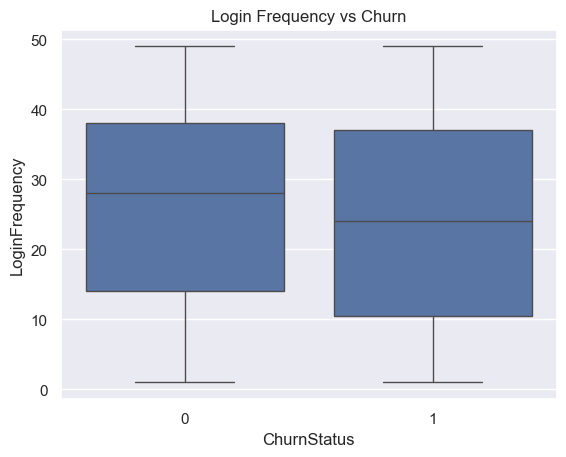

In [40]:
sns.boxplot(x='ChurnStatus',y='LoginFrequency', data=merged_df)
plt.title('Login Frequency vs Churn')

plt.show()

## TOTAL SPENDING VS CHURN

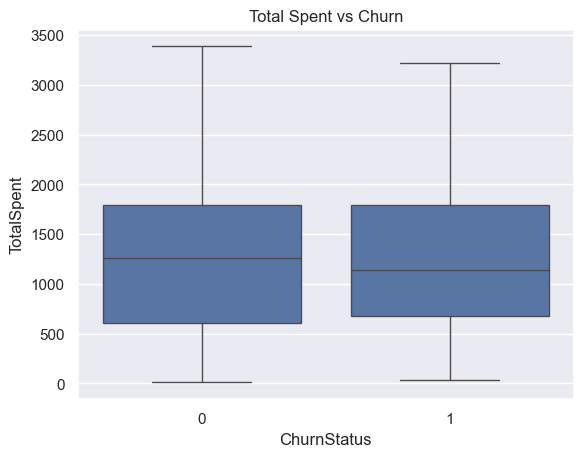

In [41]:
sns.boxplot(x='ChurnStatus',y='TotalSpent', data=merged_df)
plt.title('Total Spent vs Churn')

plt.show()

##  COMPLAINT COUNT VS CHURN

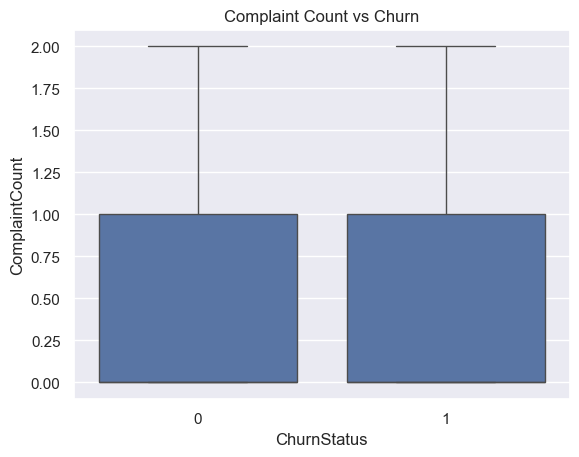

In [42]:
sns.boxplot(
    x='ChurnStatus',
    y='ComplaintCount',
    data=merged_df
)
plt.title('Complaint Count vs Churn')
plt.show()


##  UNRESOLVED COMPLAINTS VS CHURN

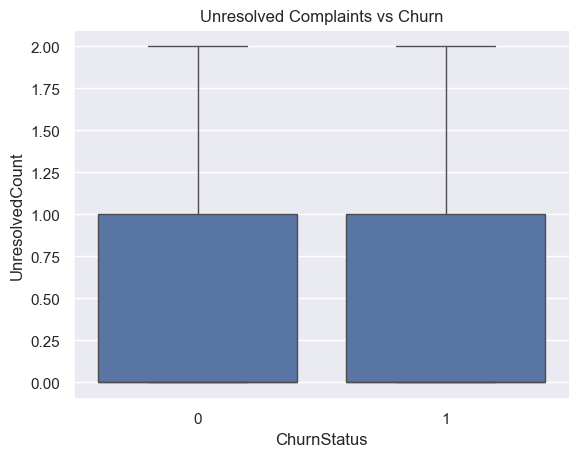

In [43]:
sns.boxplot(
    x='ChurnStatus',
    y='UnresolvedCount',
    data=merged_df
)

plt.title('Unresolved Complaints vs Churn')

plt.show()

##  CORRELATION HEATMAP

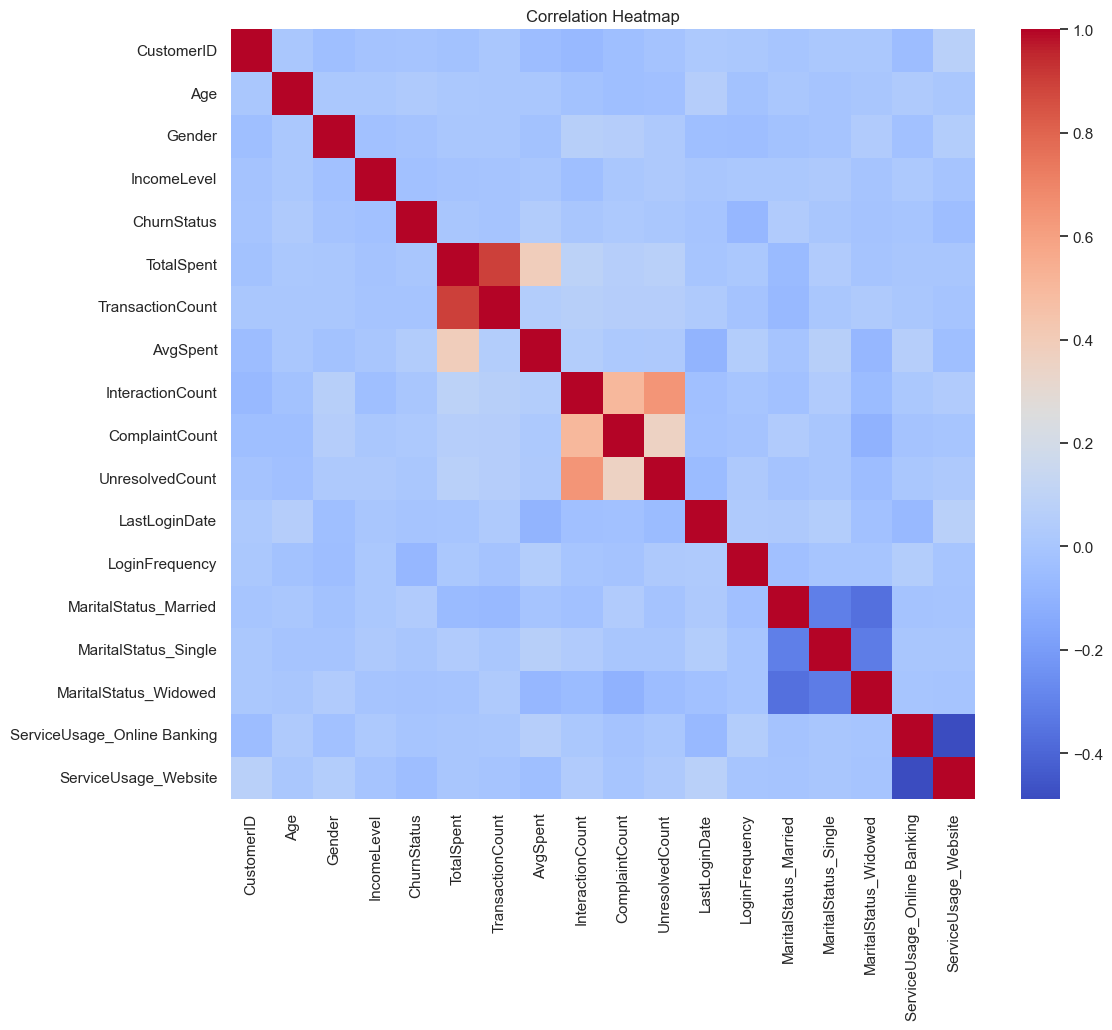

In [58]:
plt.figure(figsize=(12,10))
sns.heatmap(model_df.corr(),cmap='coolwarm',annot=False)
plt.title('Correlation Heatmap')

plt.show()

# Model

## Split the Dataset

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [46]:
cols_to_drop = ['ChurnStatus','CustomerID','LastLoginDate']
x = model_df.drop([col for col in cols_to_drop if col in model_df.columns], axis=1)
y = model_df['ChurnStatus']

In [47]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=47,stratify=y)

## Random Forest

In [48]:
model_rf = RandomForestClassifier(n_estimators=100,max_depth =  10, random_state=47)
model_rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [49]:
y_pred = model_rf.predict(x_test)
y_prob = model_rf.predict_proba(x_test)[:,1]

##  Evaluation

In [50]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

C:\Users\sankp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [51]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

Accuracy: 0.795
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC: 0.5414940941862249


In [52]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[159   0]
 [ 41   0]]


# Visualizations

## Churn Distribution

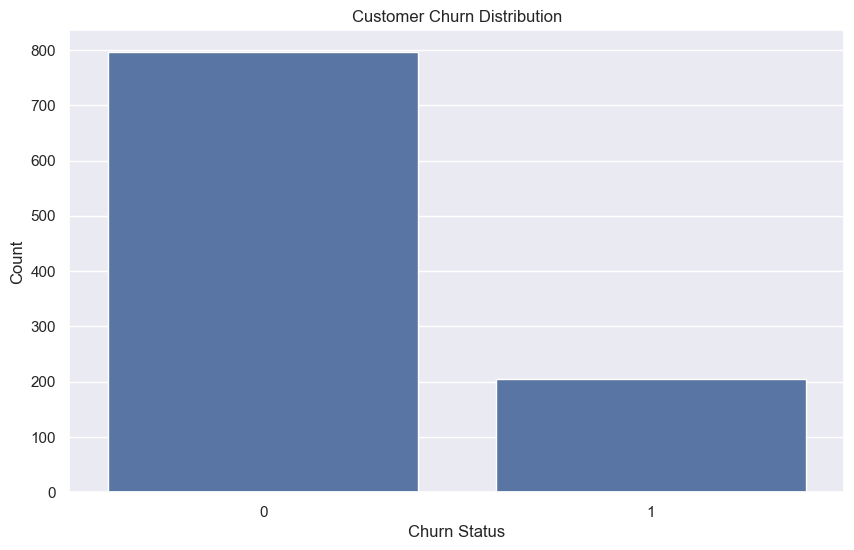

In [53]:
plt.figure(figsize=(10,6))

sns.countplot(x=y)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.show()

## Confusion Matrix

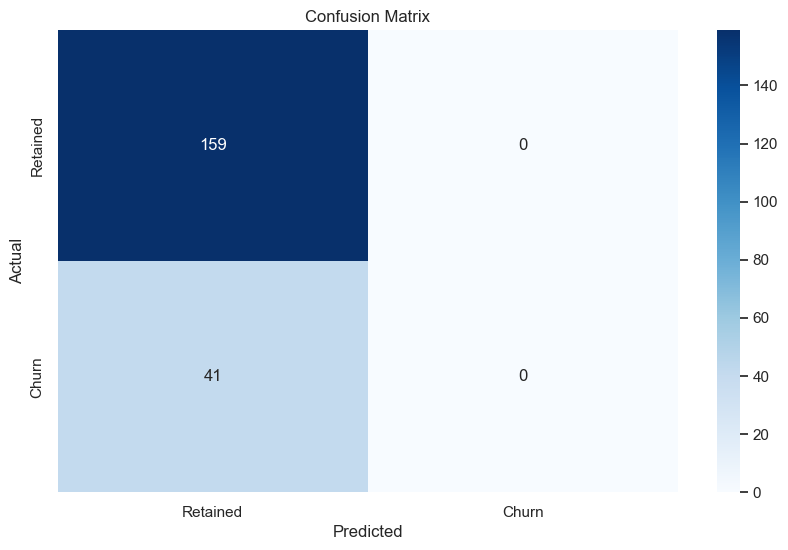

In [54]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Retained', 'Churn'],
    yticklabels=['Retained', 'Churn']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

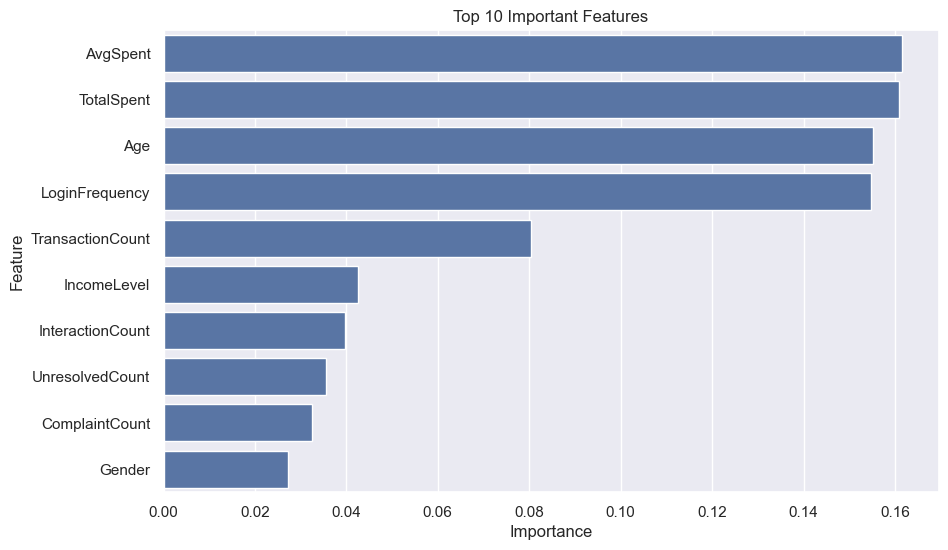

In [55]:
feature_importance = model_rf.feature_importances_

importance_df = pd.DataFrame({'Feature': x.columns,'Importance': feature_importance})

importance_df = importance_df.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(x='Importance', y='Feature',data=importance_df.head(10))

plt.title("Top 10 Important Features")

plt.show()


## Model Performance

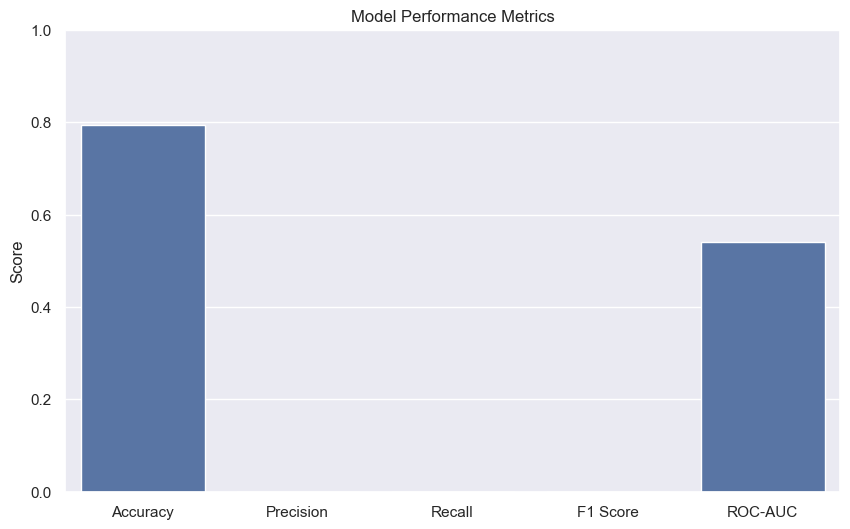

In [56]:
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC-AUC': roc_auc
}

plt.figure(figsize=(10,6))

sns.barplot(x=list(metrics.keys()), y=list(metrics.values()))

plt.ylim(0,1)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()
plt.show()


# Results

## Model Performance

In [57]:
print(f"Accuracy: {metrics['Accuracy']:.2f} %")
print(f"Precision: {metrics['Precision']:.2f} %")
print(f"Recall: {metrics['Recall']:.2f} %")
print(f"F1 Score: {metrics['F1 Score']:.2f} %")
print(f"ROC AUC: {metrics['ROC-AUC']:.2f} %")


Accuracy: 0.80 %
Precision: 0.00 %
Recall: 0.00 %
F1 Score: 0.00 %
ROC AUC: 0.54 %


## Interpretation

1. Accuracy shows overall prediction correctness.
2. Precision indicates how many predicted churn customers actually churned.
3. Recall indicates how many churned customers were correctly identified.
4. F1 Score balances Precision and Recall.
5. ROC-AUC measures model discrimination capability.

## Conclusion

The Random Forest Classification model was successfully
used to predict customer churn.

The model helps identify high-risk customers and supports
business decision-making for customer retention strategies.

Further improvements can be achieved through:
- balancing the dataset
- feature engineering
- advanced ensemble models
- threshold optimization